In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef, ConfusionMatrixDisplay


## Loading Dataset

In [2]:
# Load the dataset
X_train = pd.read_csv('X_train_selected.csv')
X_test = pd.read_csv('X_test_selected.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(712, 8) (179, 8) (712, 1) (179, 1)


In [3]:
X_train.columns

Index(['Pclass', 'SibSp', 'Parch', 'Fare', 'Age', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [4]:
X_train.isnull().sum()

Pclass        0
SibSp         0
Parch         0
Fare          0
Age           0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [5]:
y_train.value_counts()

Survived
0           444
1           268
Name: count, dtype: int64

In [6]:
y_test.value_counts()

Survived
0           105
1            74
Name: count, dtype: int64

## Defining and Traning ML Model

Model: SVC

Training Performance:
Accuracy:  0.6854
Precision: 0.6774
Recall:    0.3134
F1 Score:  0.4286
MCC:       0.2853

Test Performance:
Accuracy:  0.6760
Precision: 0.7500
Recall:    0.3243
F1 Score:  0.4528
MCC:       0.3189


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


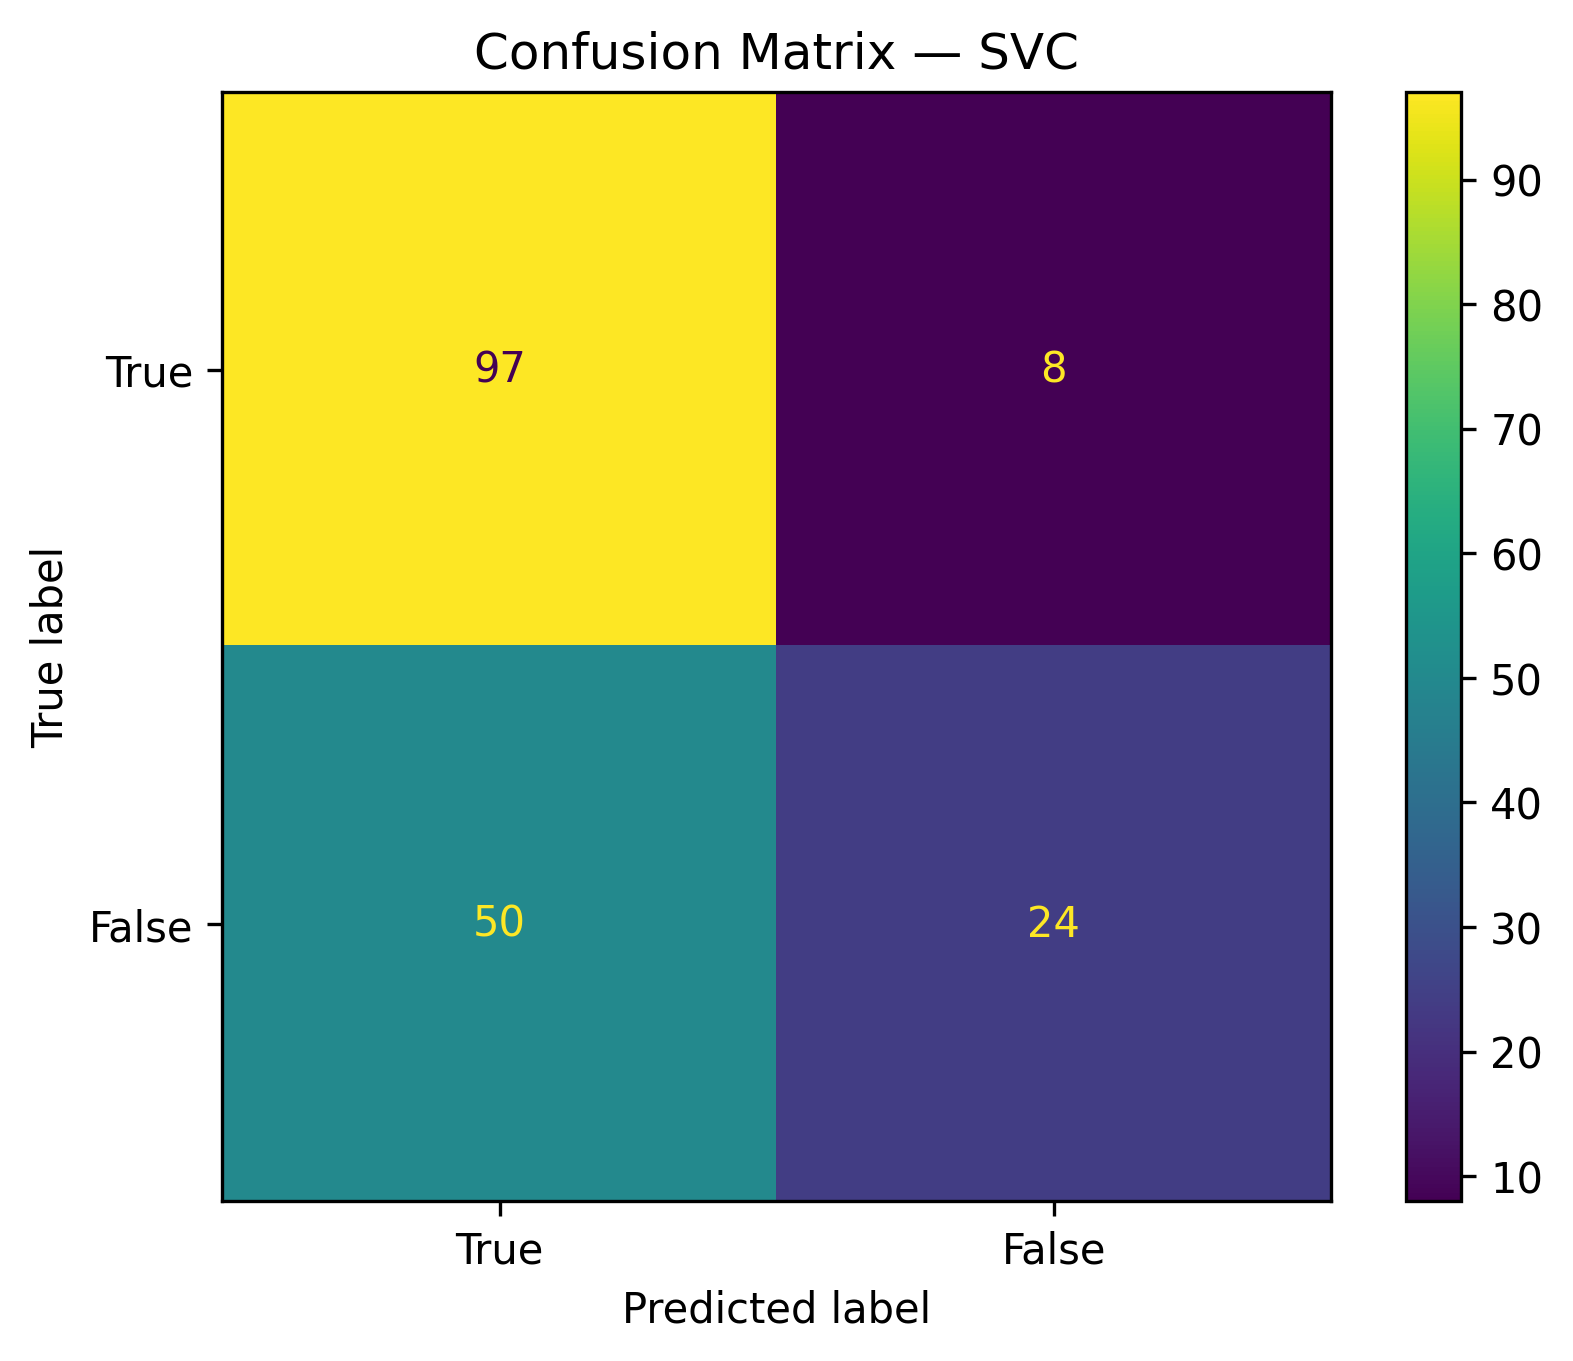

Model: DecisionTree

Training Performance:
Accuracy:  0.9817
Precision: 1.0000
Recall:    0.9515
F1 Score:  0.9751
MCC:       0.9615

Test Performance:
Accuracy:  0.7989
Precision: 0.7639
Recall:    0.7432
F1 Score:  0.7534
MCC:       0.5838


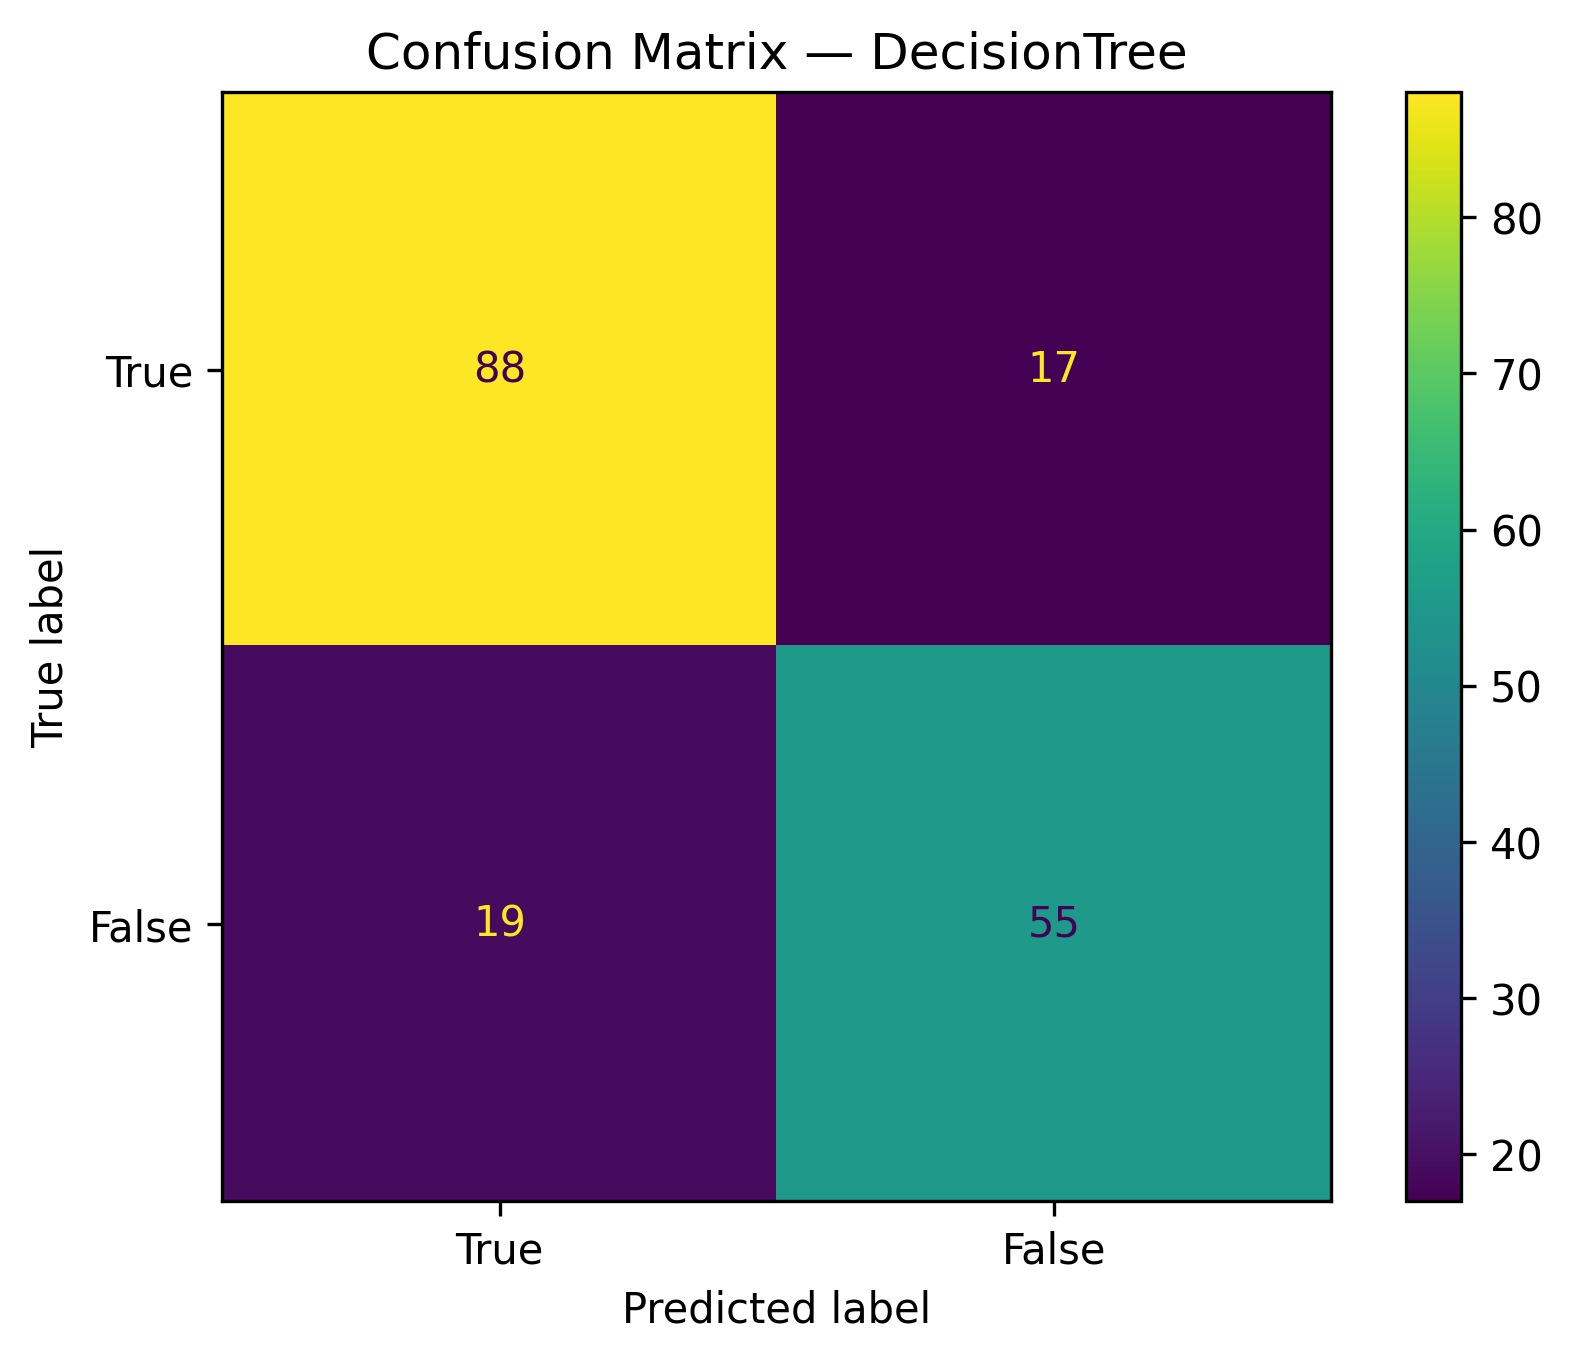

Model: GradientBoosting

Training Performance:
Accuracy:  0.8975
Precision: 0.9493
Recall:    0.7687
F1 Score:  0.8495
MCC:       0.7829

Test Performance:
Accuracy:  0.7877
Precision: 0.7727
Recall:    0.6892
F1 Score:  0.7286
MCC:       0.5576


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


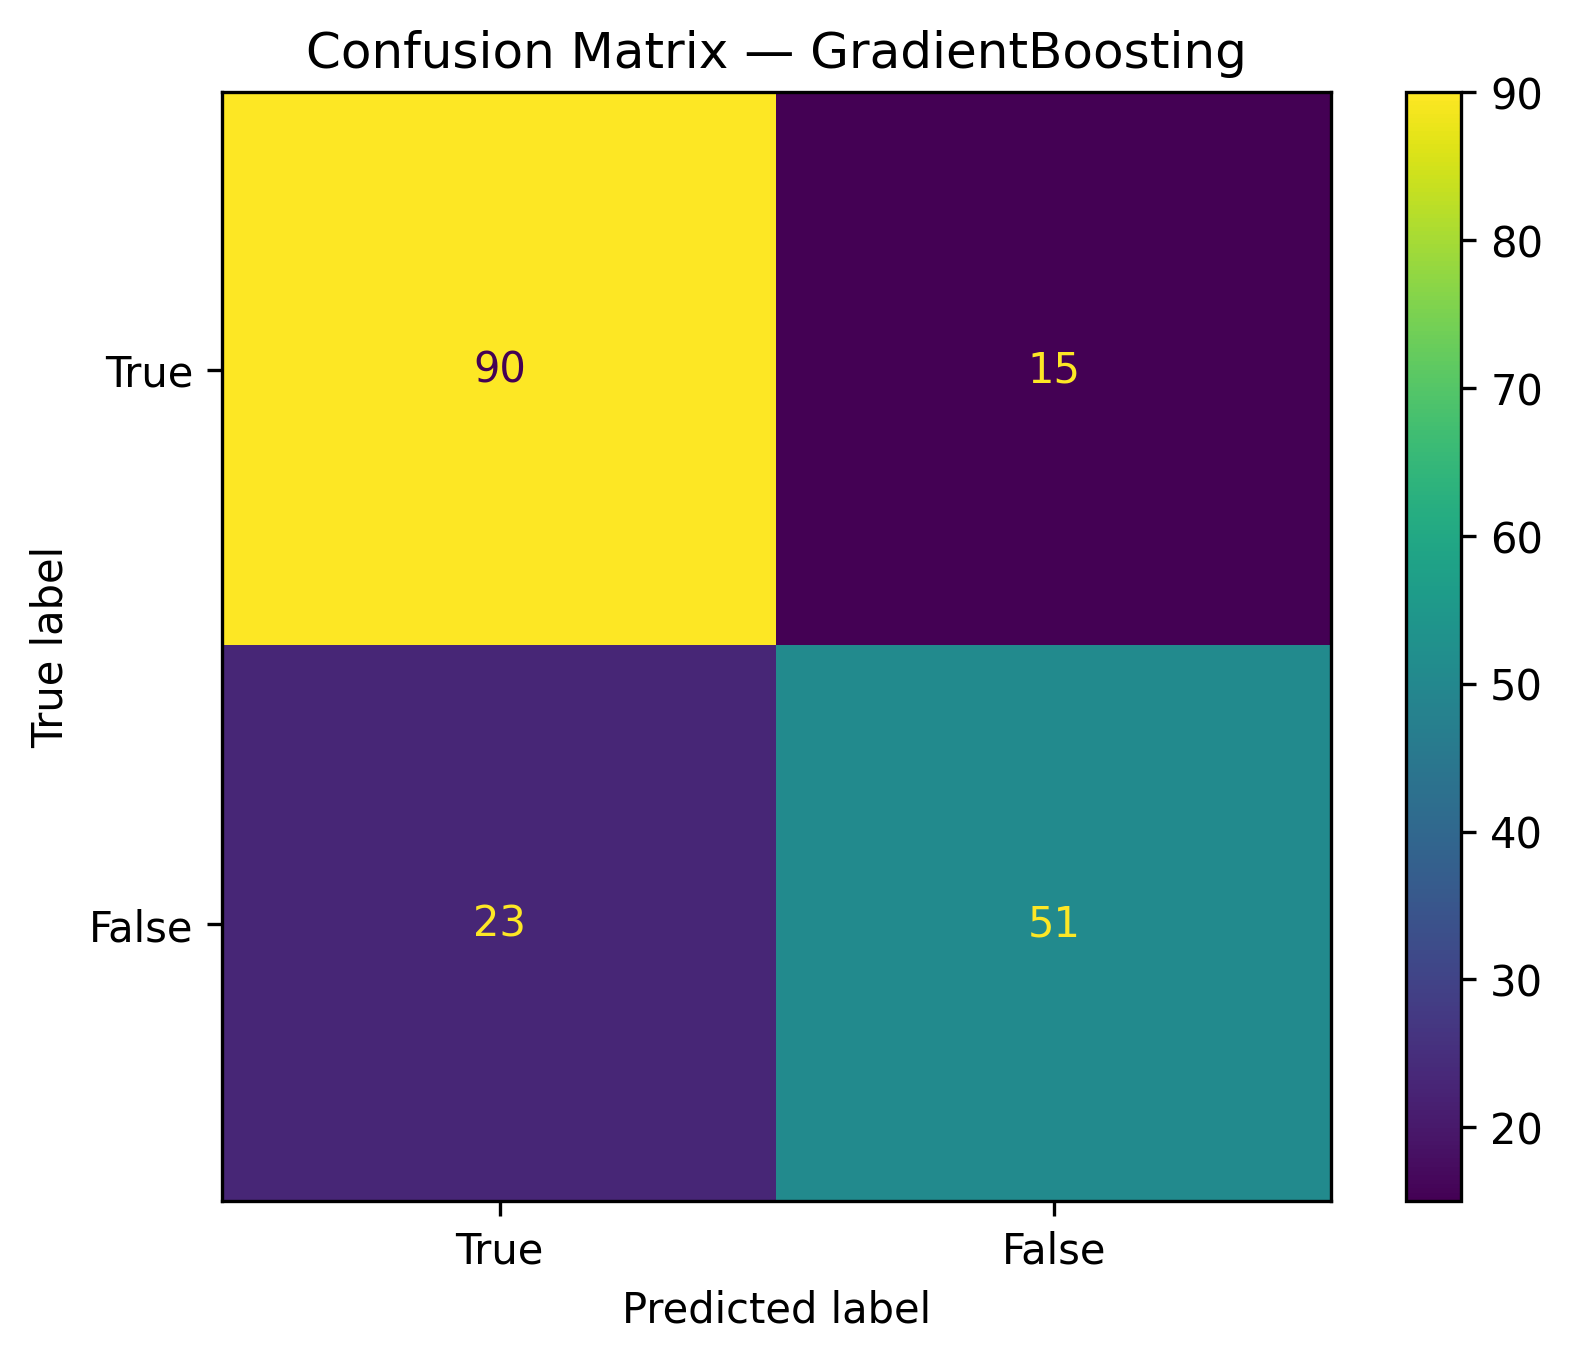

Model: Bagging (SVC base)


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\ensemble\_bagging.py:802: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Training Performance:
Accuracy:  0.6854
Precision: 0.6803
Recall:    0.3097
F1 Score:  0.4256
MCC:       0.2853

Test Performance:
Accuracy:  0.6704
Precision: 0.7419
Recall:    0.3108
F1 Score:  0.4381
MCC:       0.3053


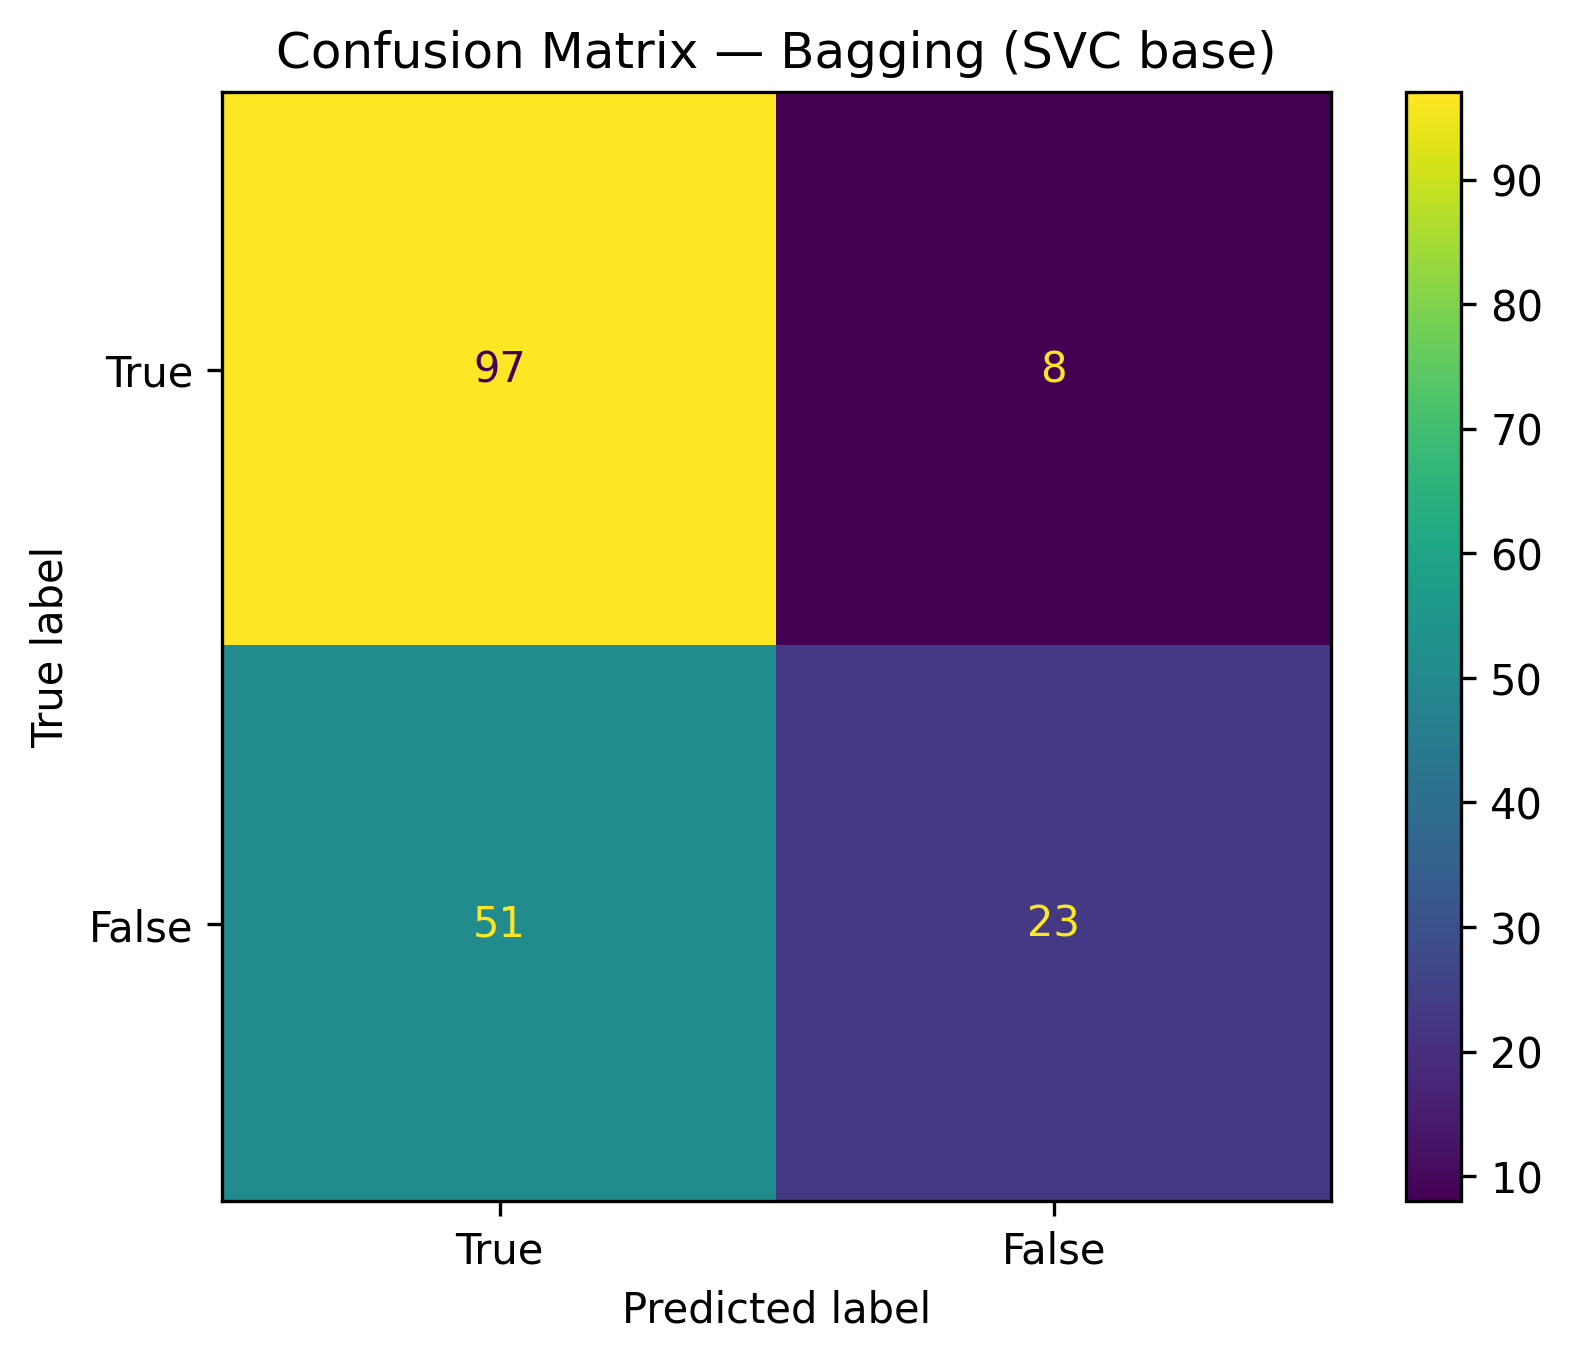

Model: RandomForest


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Training Performance:
Accuracy:  0.9817
Precision: 0.9923
Recall:    0.9590
F1 Score:  0.9753
MCC:       0.9612

Test Performance:
Accuracy:  0.8212
Precision: 0.7838
Recall:    0.7838
F1 Score:  0.7838
MCC:       0.6314


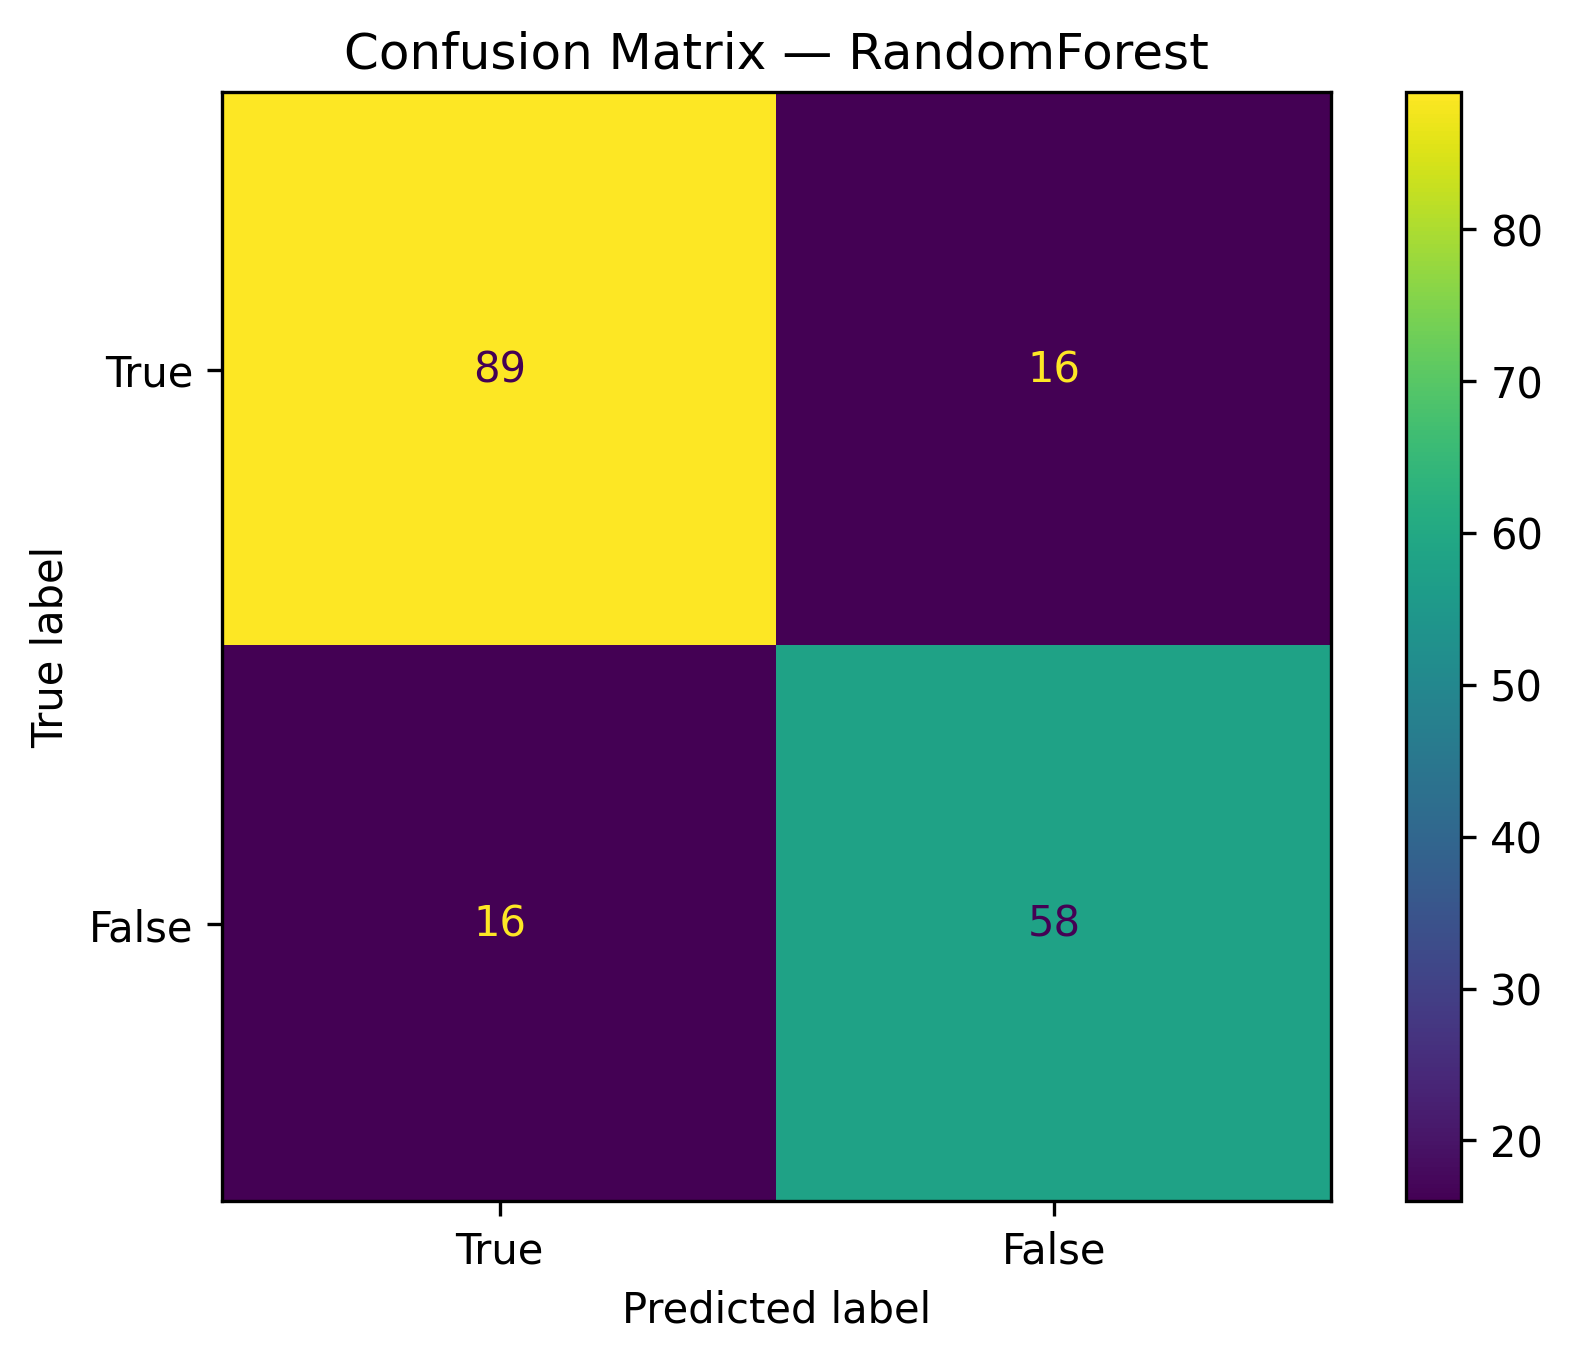

Model: Stacking


C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)



Training Performance:
Accuracy:  0.7739
Precision: 0.6890
Recall:    0.7276
F1 Score:  0.7078
MCC:       0.5241

Test Performance:
Accuracy:  0.7430
Precision: 0.6707
Recall:    0.7432
F1 Score:  0.7051
MCC:       0.4804


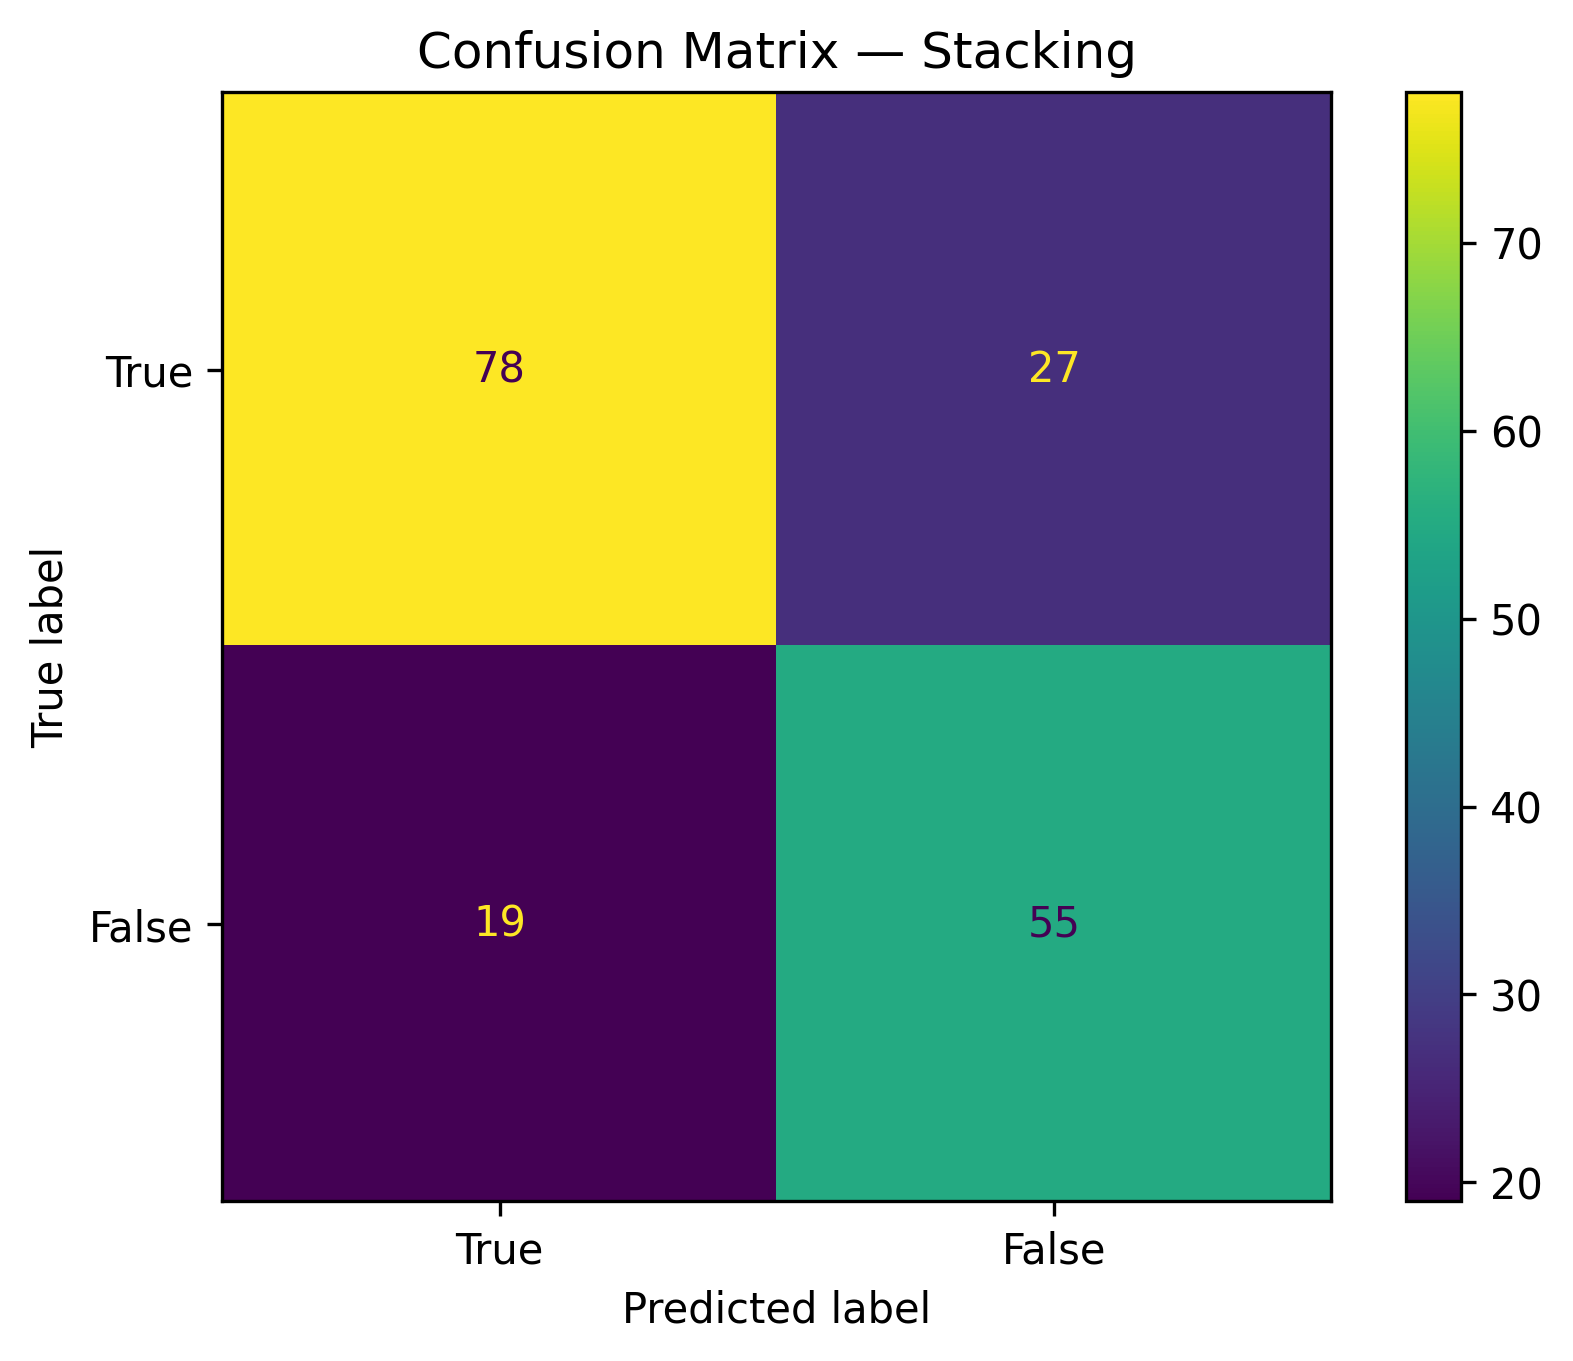

In [7]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# ======================
# Define all models
# ======================
models = {
    "SVC": SVC(kernel='rbf', random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "Bagging (SVC base)": BaggingClassifier(estimator=SVC(kernel='rbf'),random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "Stacking": StackingClassifier(
        estimators=[
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('svc', SVC(kernel='rbf', random_state=42)),
            ('rf', RandomForestClassifier(random_state=42))
        ],
        final_estimator=DecisionTreeClassifier(random_state=42)
    )
}

# ======================
# Train & Evaluate
# ======================
for name, clf in models.items():
    print("="*60)
    print(f"Model: {name}")
    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Training metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_mcc = matthews_corrcoef(y_train, y_train_pred)

    # Test metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_mcc = matthews_corrcoef(y_test, y_test_pred)

    # Print results
    print("\nTraining Performance:")
    print(f"Accuracy:  {train_acc:.4f}")
    print(f"Precision: {train_prec:.4f}")
    print(f"Recall:    {train_rec:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")
    print(f"MCC:       {train_mcc:.4f}")

    print("\nTest Performance:")
    print(f"Accuracy:  {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall:    {test_rec:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"MCC:       {test_mcc:.4f}")

    # Confusion Matrix (Test)
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[True, False])
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


## ML Models with Parameter Tuning

🔍 Tuning and training model: SVC
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best CV Accuracy: 0.7149


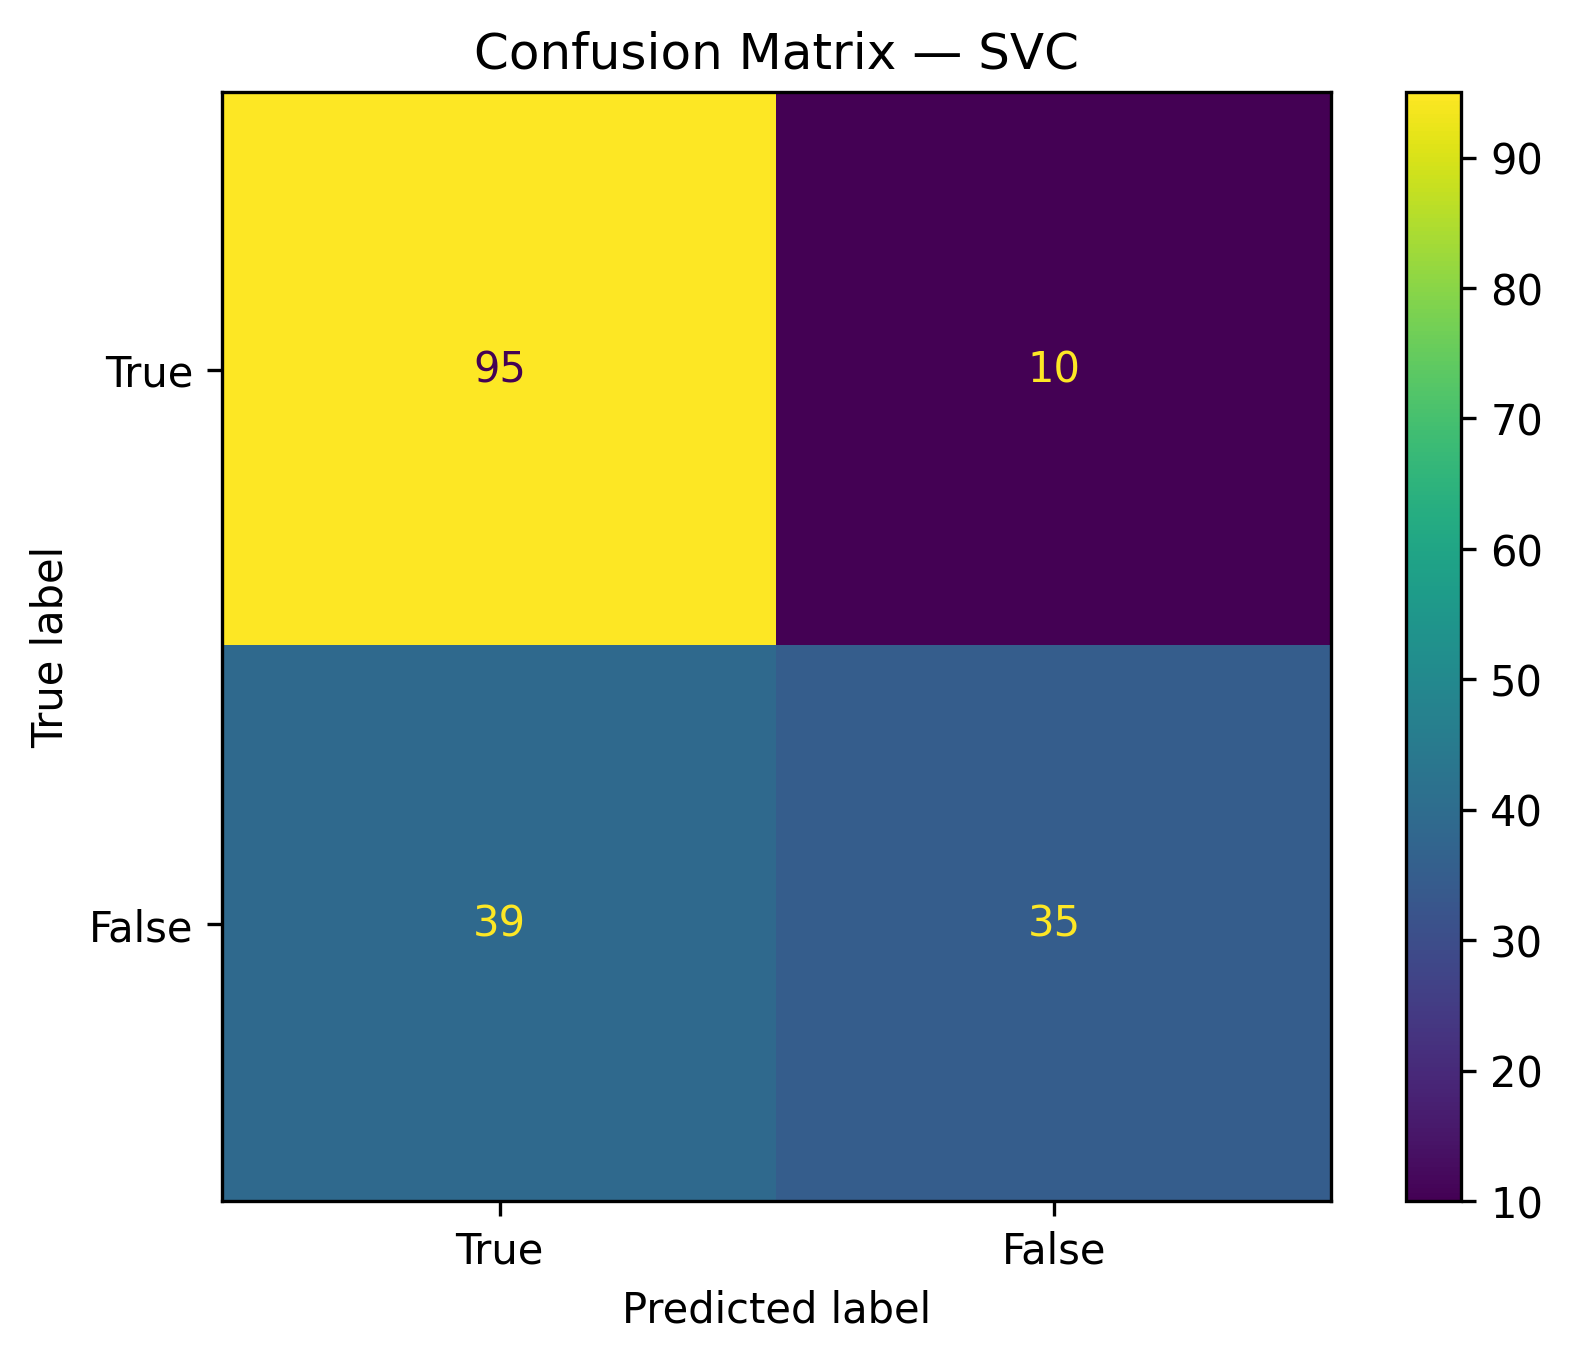

🔍 Tuning and training model: DecisionTree
Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best CV Accuracy: 0.8188


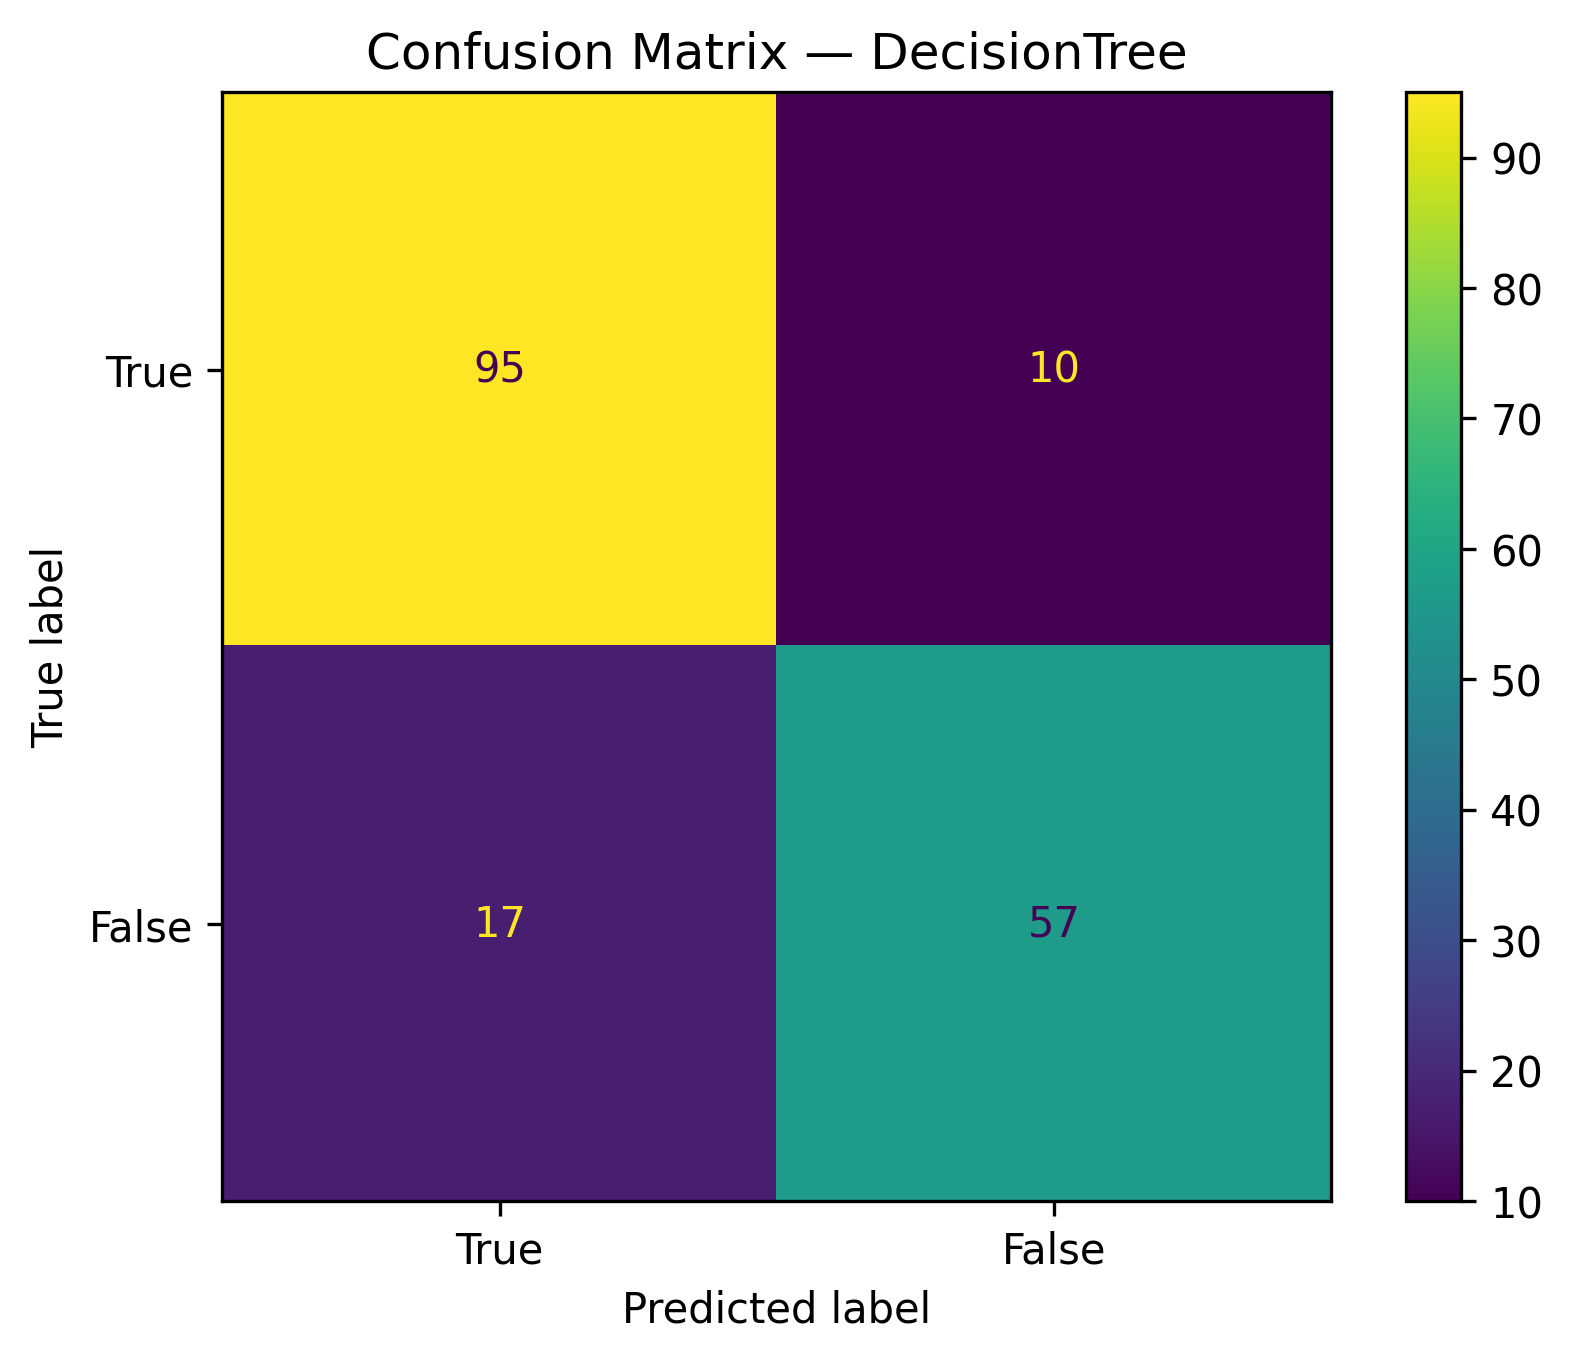

🔍 Tuning and training model: GradientBoosting
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Accuracy: 0.8259


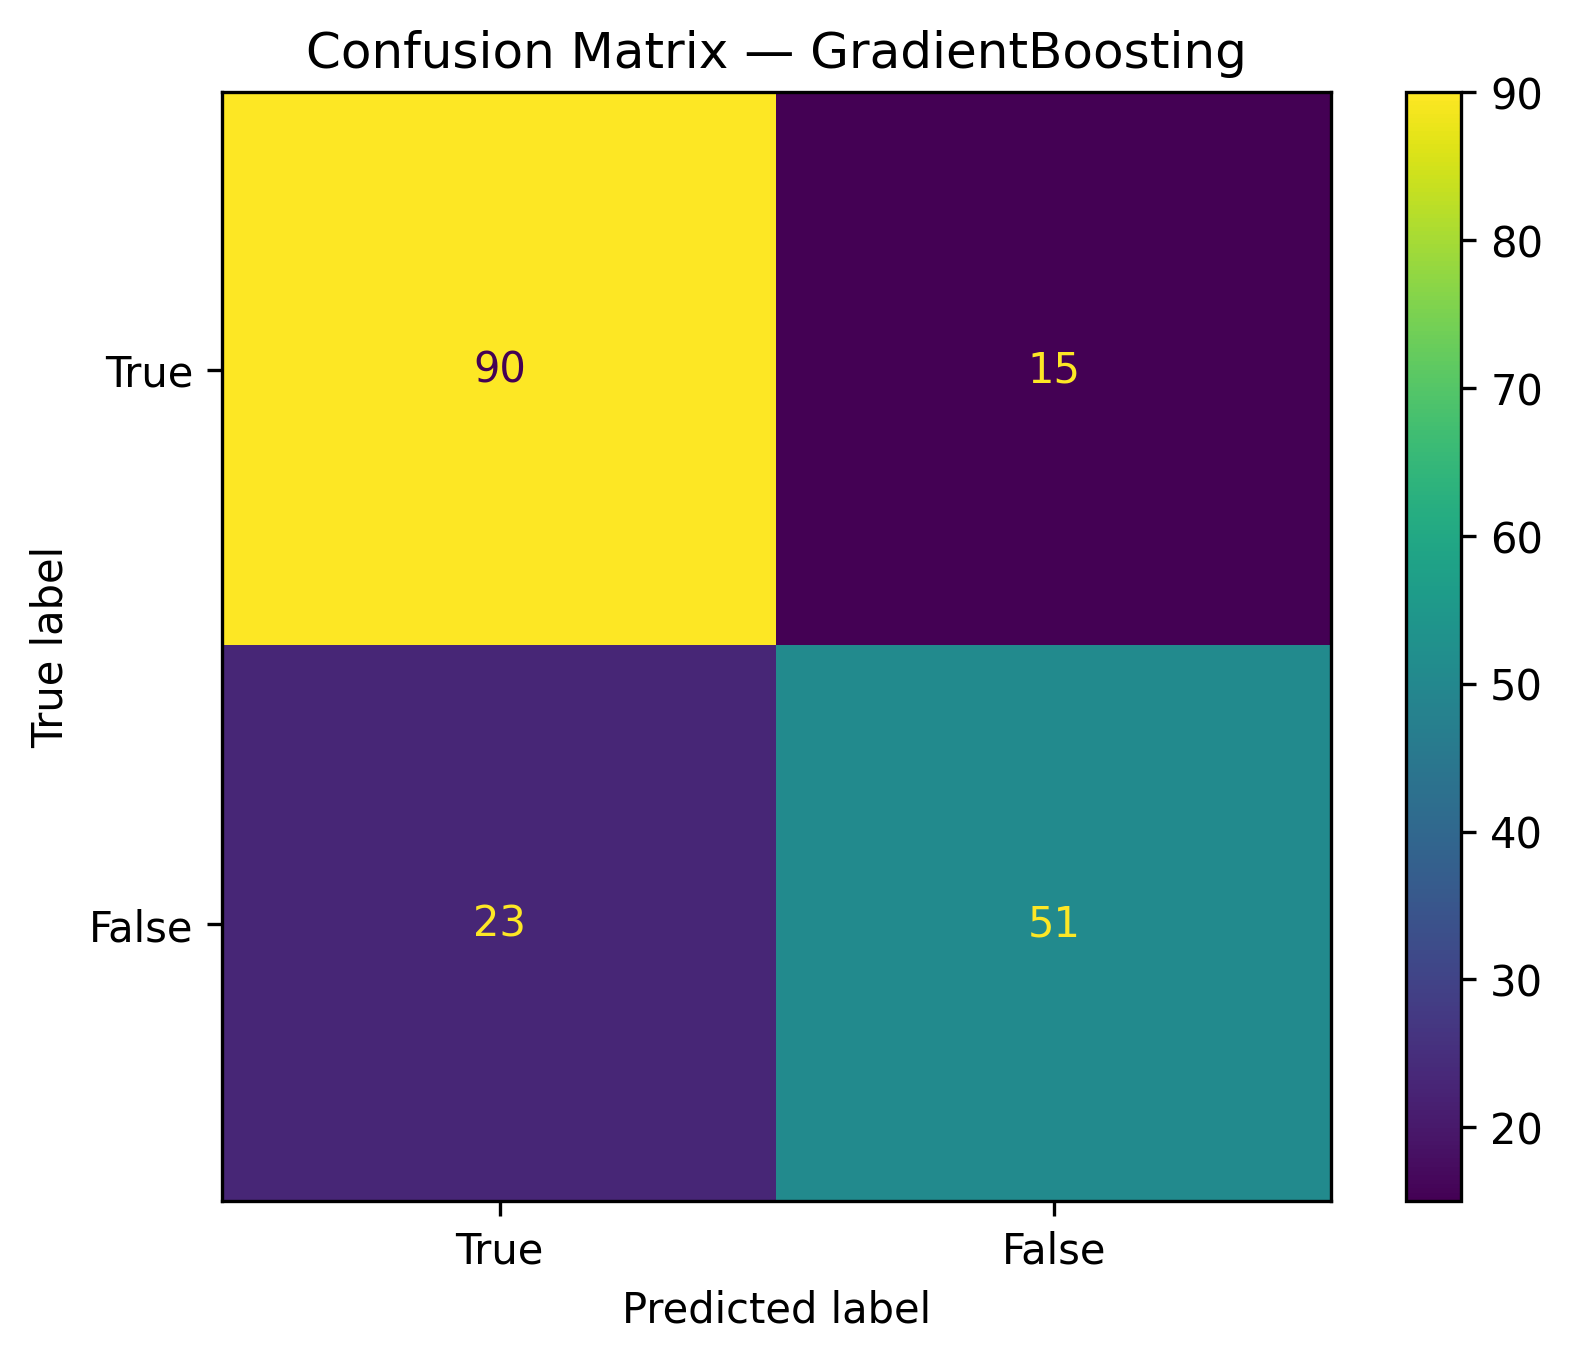

🔍 Tuning and training model: Bagging (SVC base)
Best Parameters: {'max_samples': 1.0, 'n_estimators': 30}
Best CV Accuracy: 0.6825


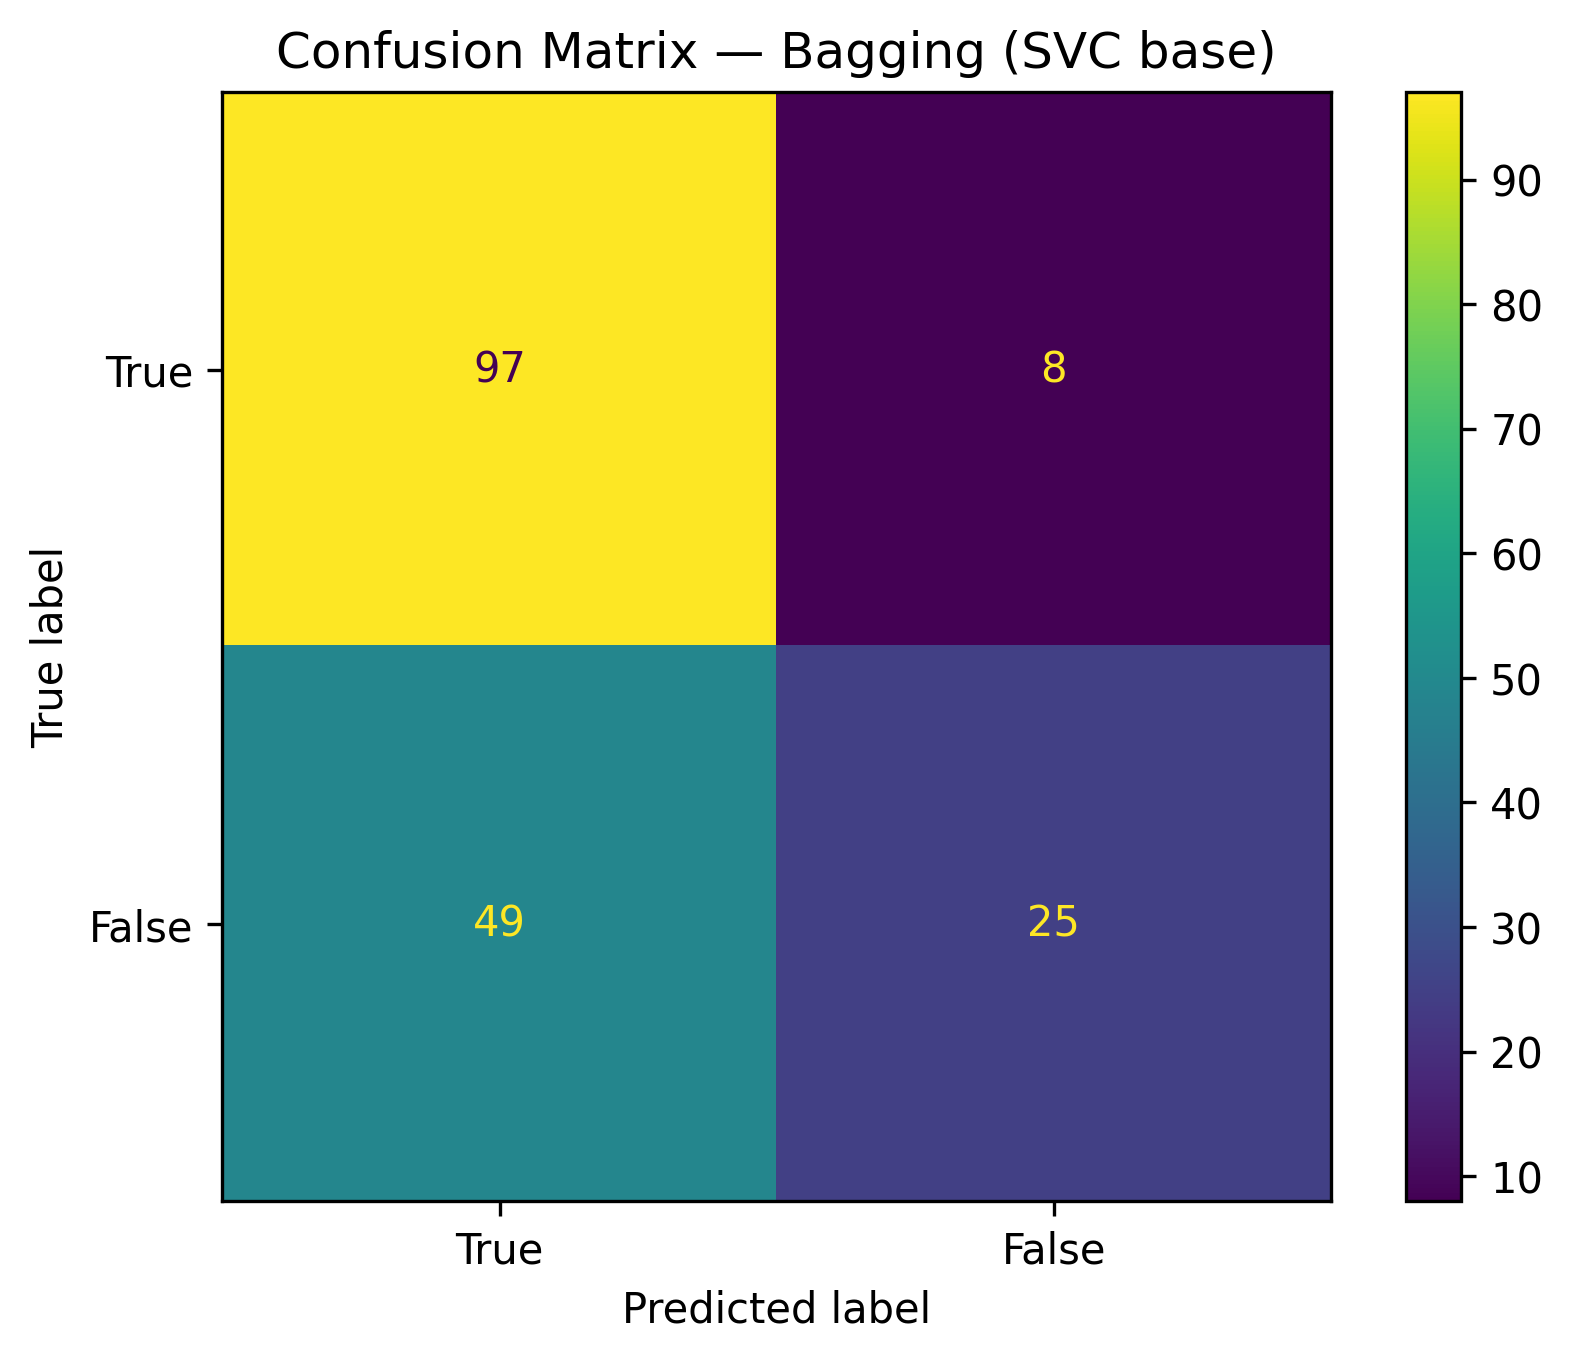

🔍 Tuning and training model: RandomForest
Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV Accuracy: 0.8132


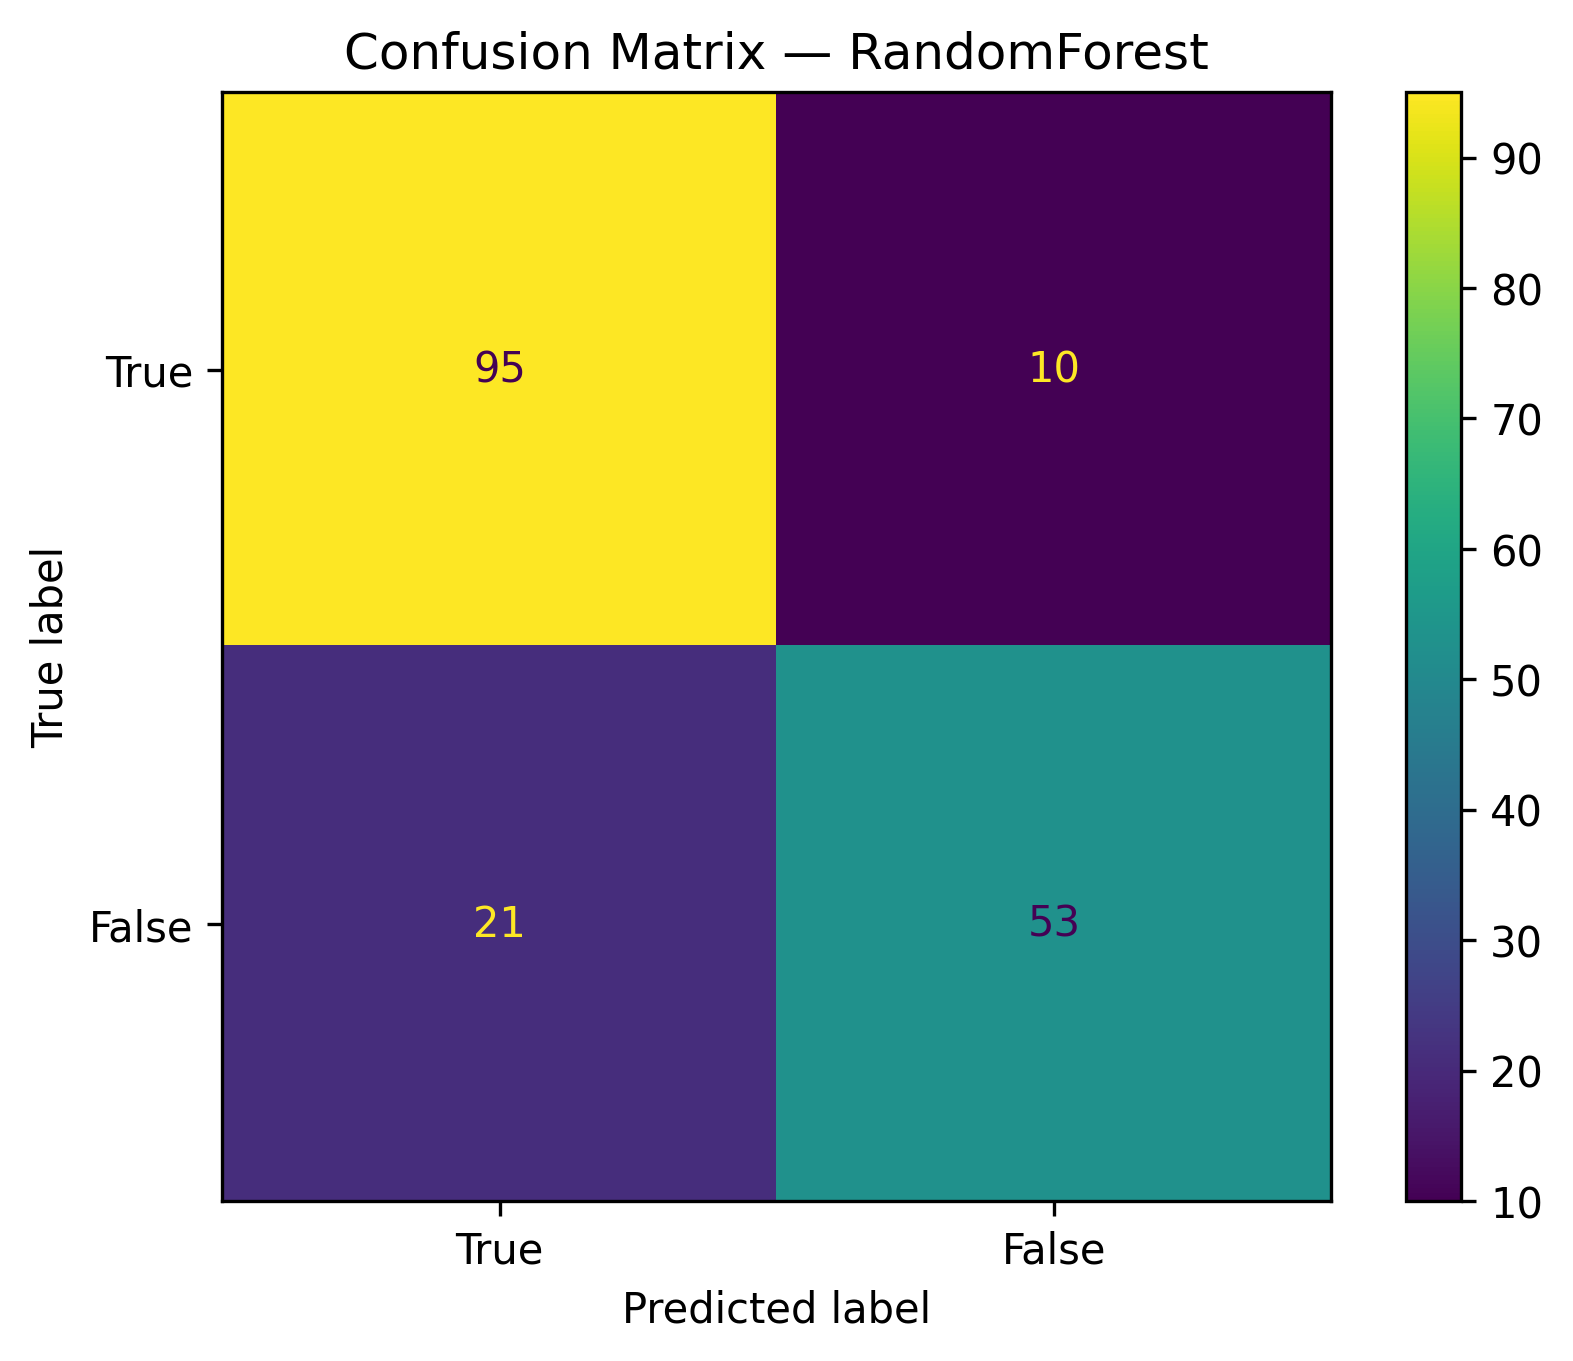

⚙️ Training Stacking Classifier


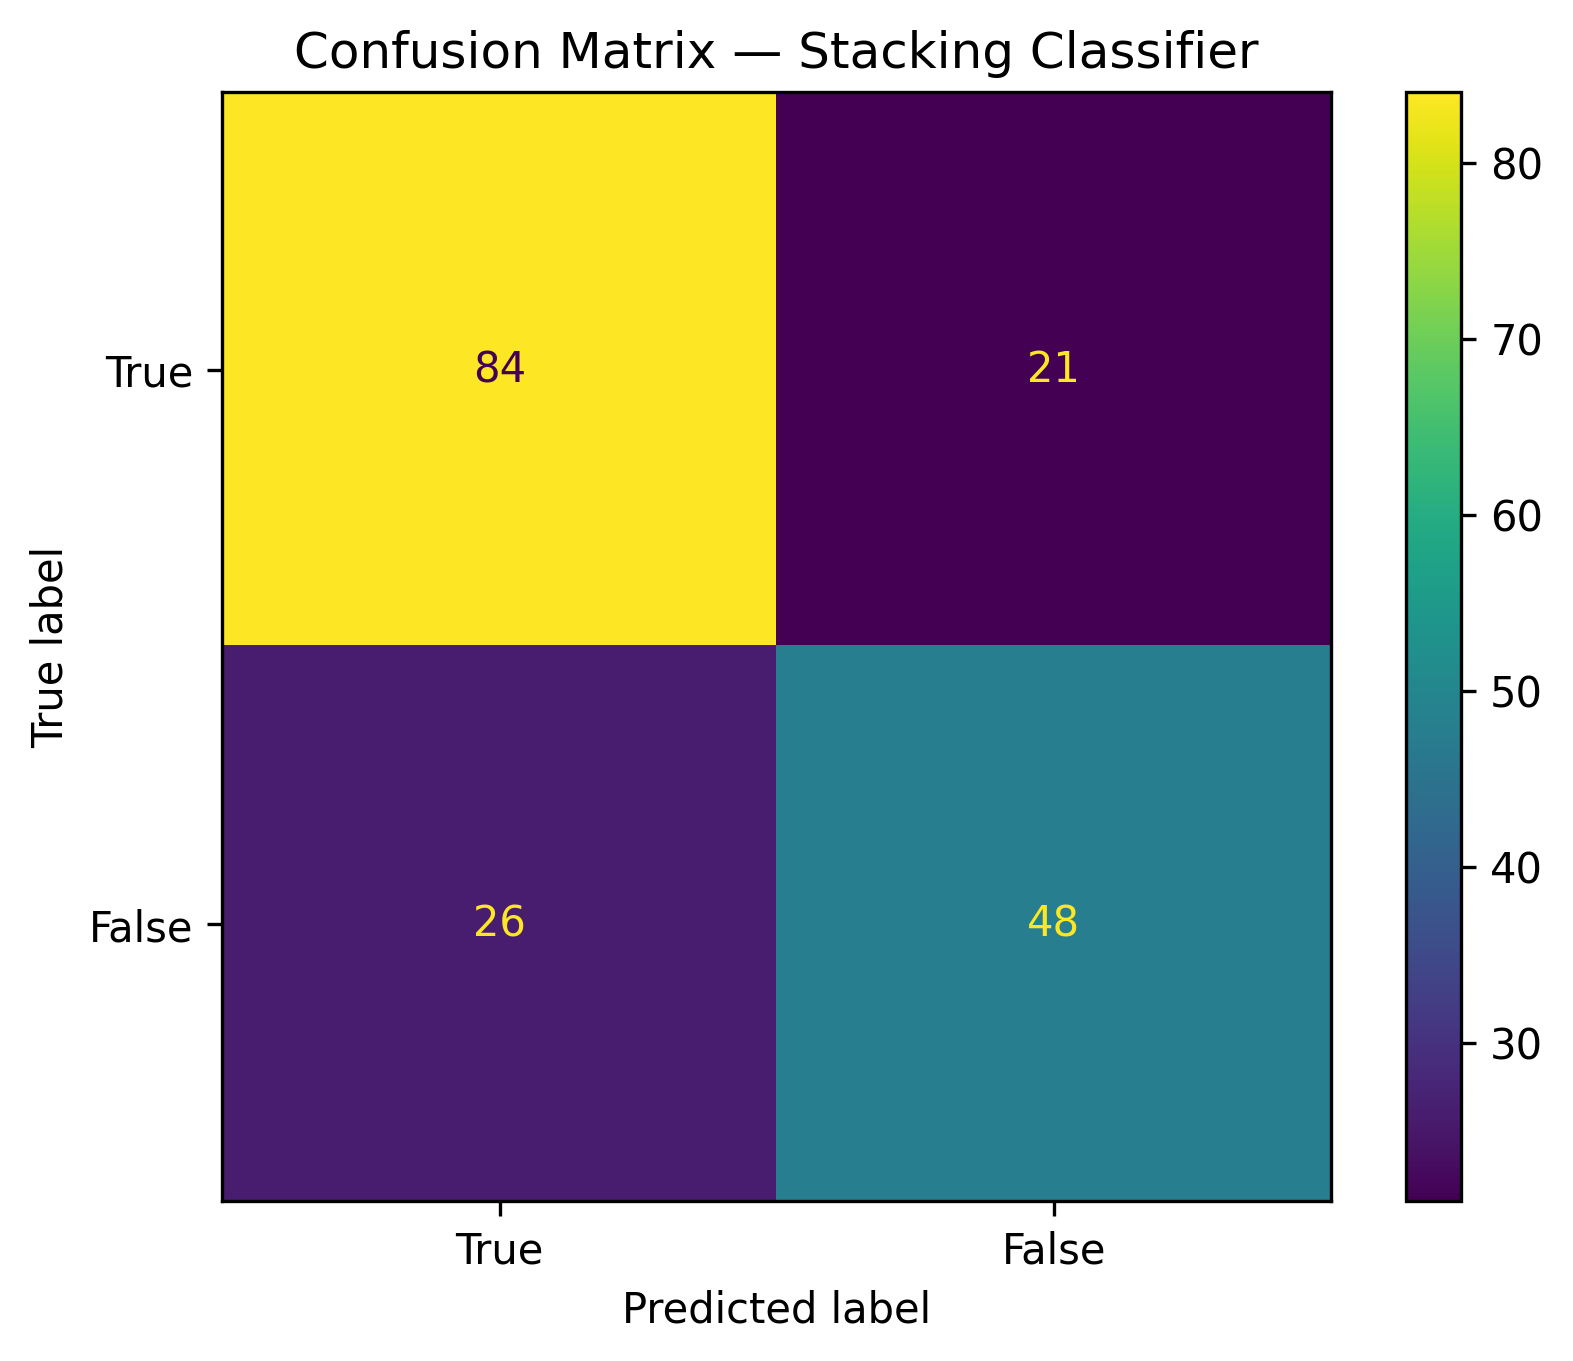


📊 Model Performance Summary:
                Model  Train_Accuracy  Train_Precision  Train_Recall  \
0                 SVC          0.7177           0.7081        0.4254   
1        DecisionTree          0.8680           0.8884        0.7425   
2    GradientBoosting          0.8975           0.9493        0.7687   
3  Bagging (SVC base)          0.6812           0.6614        0.3134   
4        RandomForest          0.9087           0.9593        0.7910   
5            Stacking          0.8118           0.7991        0.6679   

   Train_F1  Train_MCC  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  \
0    0.5315     0.3701         0.7263          0.7778       0.4730   0.5882   
1    0.8089     0.7160         0.8492          0.8507       0.7703   0.8085   
2    0.8495     0.7829         0.7877          0.7727       0.6892   0.7286   
3    0.4253     0.2741         0.6816          0.7576       0.3378   0.4673   
4    0.8671     0.8071         0.8268          0.8413       0.7162   0

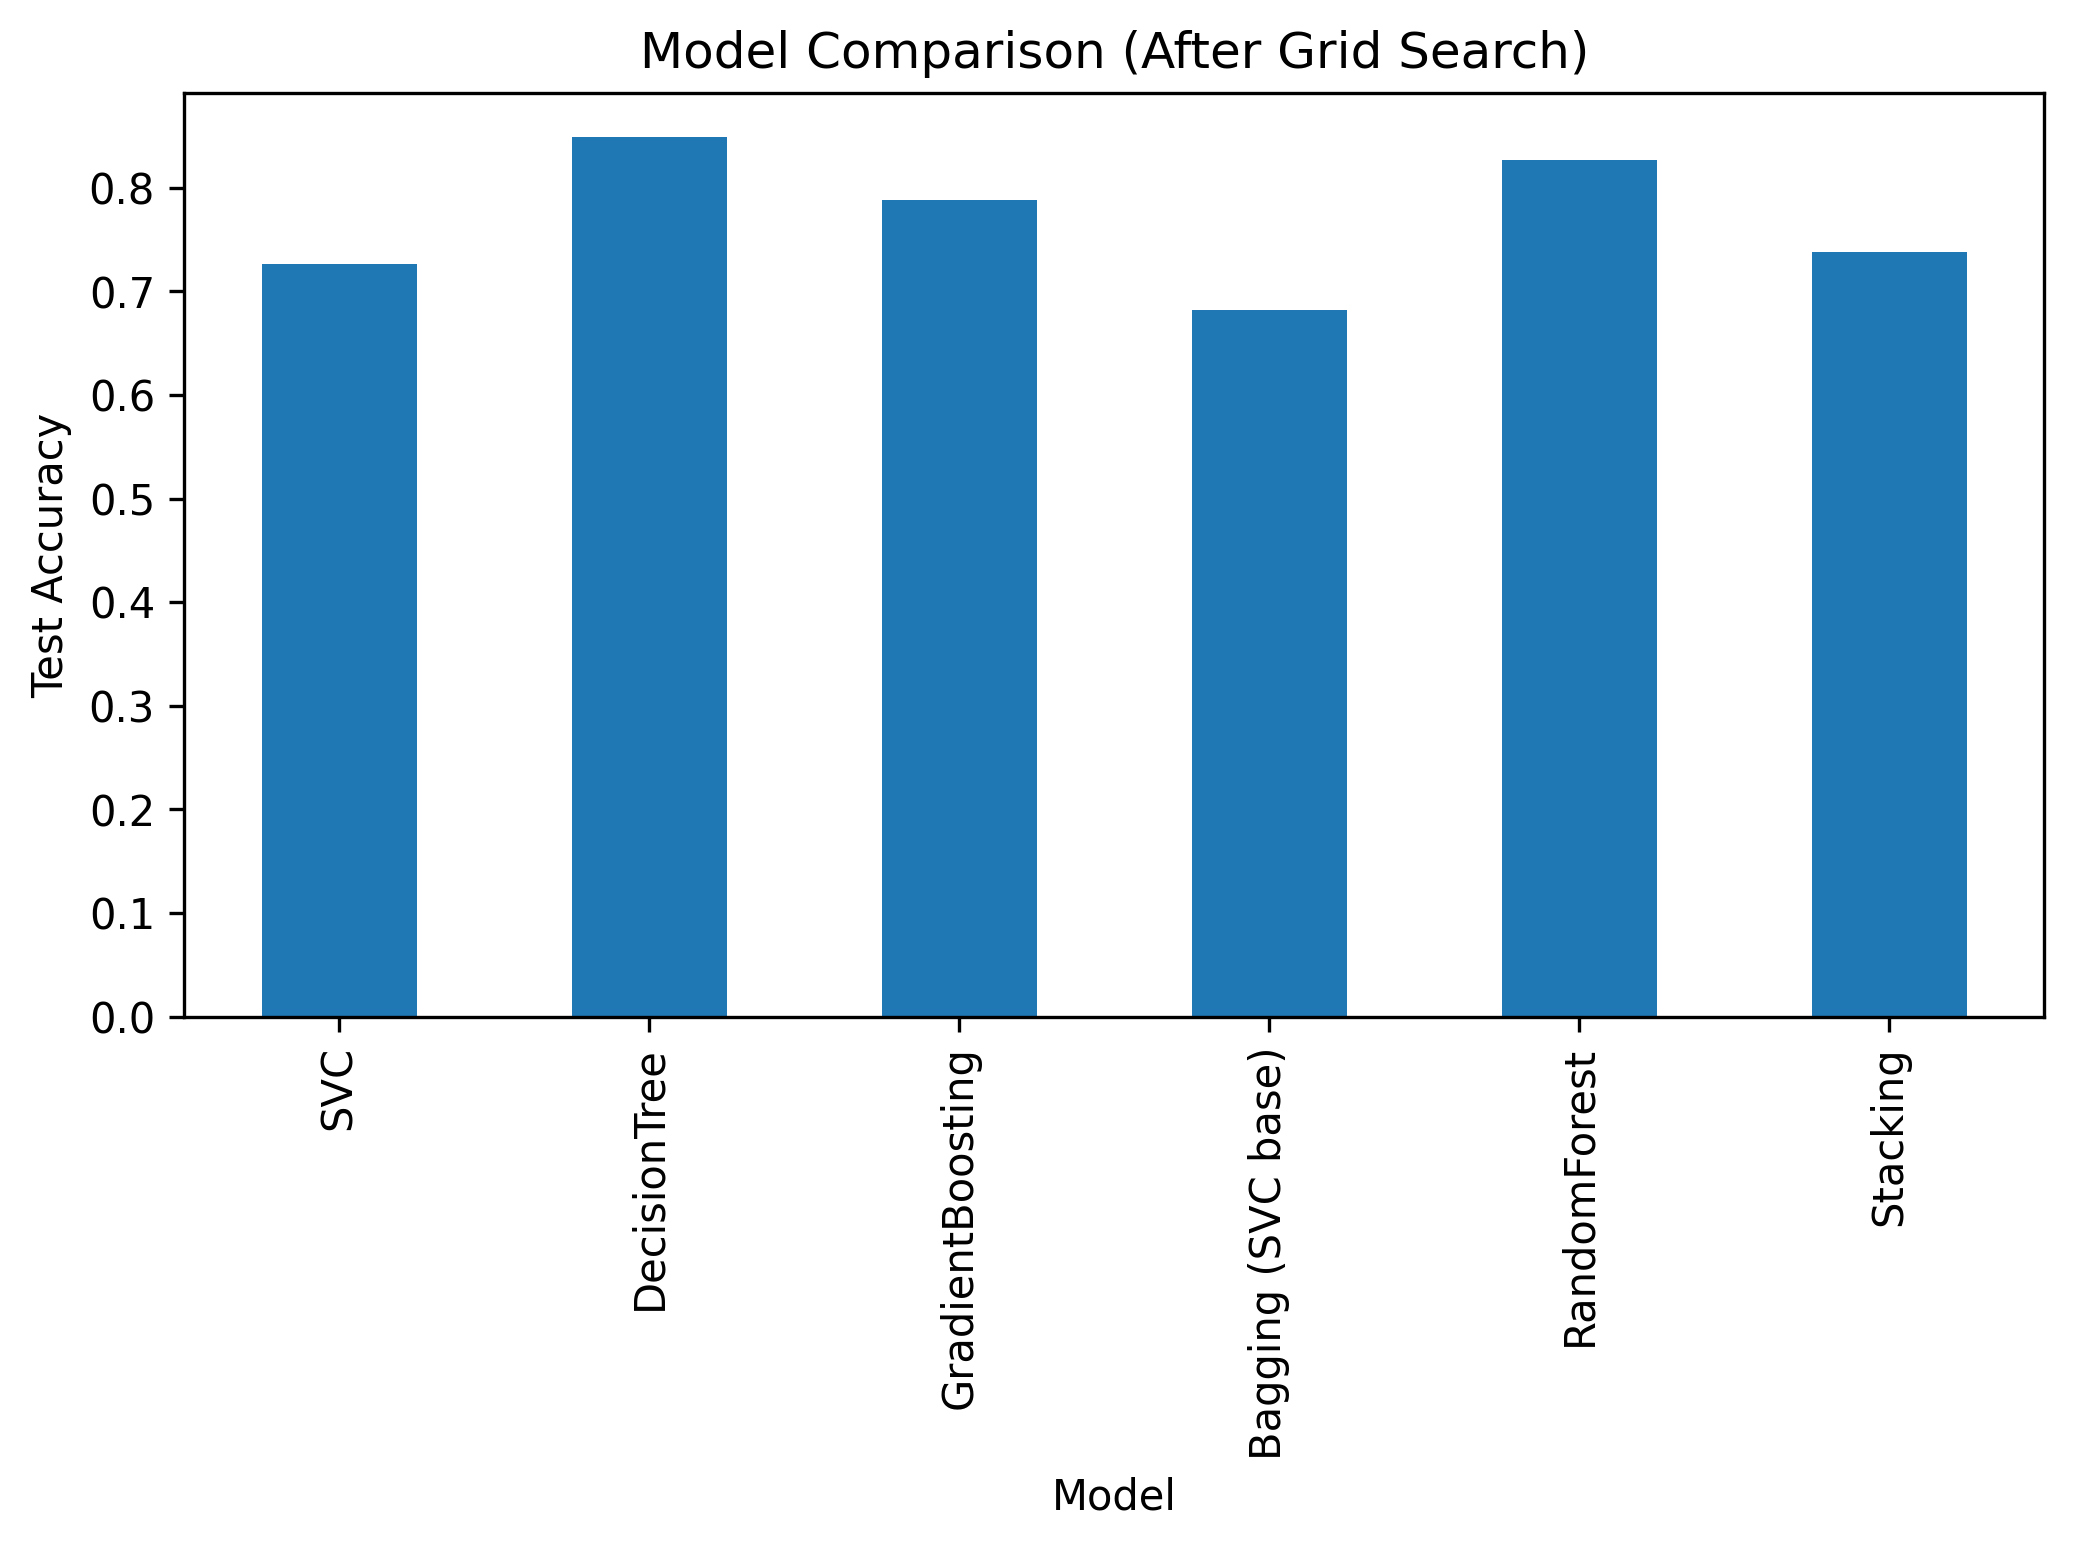

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ====================================================
# Define models with parameter grids for tuning
# ====================================================
model_params = {
    "SVC": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "poly"],
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [8, 12, 16],
            "criterion": ["gini", "entropy"],
            "min_samples_split": [5, 10, 20],
            "min_samples_leaf": [2, 5]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    },
    "Bagging (SVC base)": {
        "model": BaggingClassifier(estimator=SVC(kernel='rbf'), random_state=42),
        "params": {
            "n_estimators": [10, 20, 30],
            "max_samples": [0.5, 0.8, 1.0]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [8, 12, 16],
            "max_features": ["sqrt", "log2"]
        }
    }
}

# ====================================================
# Stacking model separately defined
# ====================================================
base_estimators = [
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]
final_estimator = DecisionTreeClassifier(max_depth=10, random_state=42)
stacking_model = StackingClassifier(estimators=base_estimators, final_estimator=final_estimator)

# ====================================================
# Train, tune and evaluate all models
# ====================================================
results = []

for name, mp in model_params.items():
    print("=" * 70)
    print(f"🔍 Tuning and training model: {name}")
    grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Best CV Accuracy: {grid.best_score_:.4f}")

    # Evaluate on training and test data
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    metrics = {
        "Model": name,
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Train_Precision": precision_score(y_train, y_train_pred),
        "Train_Recall": recall_score(y_train, y_train_pred),
        "Train_F1": f1_score(y_train, y_train_pred),
        "Train_MCC": matthews_corrcoef(y_train, y_train_pred),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_Precision": precision_score(y_test, y_test_pred),
        "Test_Recall": recall_score(y_test, y_test_pred),
        "Test_F1": f1_score(y_test, y_test_pred),
        "Test_MCC": matthews_corrcoef(y_test, y_test_pred)
    }
    results.append(metrics)

    # Plot confusion matrix (test)
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[True, False])
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

# ====================================================
# Evaluate Stacking model (no grid tuning)
# ====================================================
print("=" * 70)
print("⚙️ Training Stacking Classifier")
stacking_model.fit(X_train, y_train)
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test)

stack_metrics = {
    "Model": "Stacking",
    "Train_Accuracy": accuracy_score(y_train, y_train_pred),
    "Train_Precision": precision_score(y_train, y_train_pred),
    "Train_Recall": recall_score(y_train, y_train_pred),
    "Train_F1": f1_score(y_train, y_train_pred),
    "Train_MCC": matthews_corrcoef(y_train, y_train_pred),
    "Test_Accuracy": accuracy_score(y_test, y_test_pred),
    "Test_Precision": precision_score(y_test, y_test_pred),
    "Test_Recall": recall_score(y_test, y_test_pred),
    "Test_F1": f1_score(y_test, y_test_pred),
    "Test_MCC": matthews_corrcoef(y_test, y_test_pred)
}
results.append(stack_metrics)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[True, False])
disp.plot()
plt.title("Confusion Matrix — Stacking Classifier")
plt.show()

# ====================================================
# Summary Table
# ====================================================
df_results = pd.DataFrame(results)
print("\n📊 Model Performance Summary:")
print(df_results.round(4))

# Optional: visualize test accuracy comparison
df_results.plot(x='Model', y='Test_Accuracy', kind='bar', legend=False, figsize=(8,4))
plt.ylabel("Test Accuracy")
plt.title("Model Comparison (After Grid Search)")
plt.show()
